# Notebook 05 — Test du modèle XGBoost LIAR sur BuzzFeed dataset

**Dataset** : `data_set_random_02/` — BuzzFeed_fake_news_content.csv + BuzzFeed_real_news_content.csv  
Toutes les colonnes sauf `label` sont concaténées en un seul champ texte.

**Modèle** : XGBoost pré-entraîné sur le LIAR dataset (`interface_web/model.pkl`)  
**TF-IDF** : vocabulaire LIAR (`interface_web/vectorizer.pkl`) — `.transform()` uniquement  
**Labels** : `0 = Fake`, `1 = Real`  
**Évaluation** : Accuracy, F1-score, ROC-AUC, matrice de confusion.

## 0. Imports

In [7]:
import pickle
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

ROOT      = Path("..").resolve()
DATA_DIR  = ROOT / "data_set_random_02"
IFACE_DIR = ROOT / "interface_web"

## 1. Chargement et mélange aléatoire

In [8]:
fake = pd.read_csv(DATA_DIR / "BuzzFeed_fake_news_content.csv")
real = pd.read_csv(DATA_DIR / "BuzzFeed_real_news_content.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# y utilisé pour l'entraînement, pas pour l'évaluation
y         = df["label"].values
text_cols = [c for c in df.columns if c != "label"]
print(f"Colonnes utilisées : {text_cols}")

for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

X = df[text_cols].apply(lambda row: " ".join(row.values), axis=1)

print(f"\nDataset total : {len(df)} articles")
print(f"Fake (0) : {(y==0).sum()} | Real (1) : {(y==1).sum()}")
print(f"\nExemple d'entrée (tronqué) :\n{X.iloc[0][:300]}")

Colonnes utilisées : ['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']

Dataset total : 182 articles
Fake (0) : 91 | Real (1) : 91

Exemple d'entrée (tronqué) :
Fake_27-Webpage How Democrats are Going to Try to STEAL the Election for Hillary – Eagle Rising In every state there is a law governing the method and procedure for conducting elections. The National Democratic Party, a “powerful hate group,” has been engaged in an all-out effort to steal elections,


## 1.5. Preprocessing — même pipeline que LIAR (lowercase, stopwords, lemmatisation)

In [9]:
_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def preprocess(text: str) -> str:
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        _lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in _stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

print("Preprocessing en cours...")
X = X.apply(preprocess)
print(f"Exemple préprocessé (tronqué) :\n{X.iloc[0][:300]}")

Preprocessing en cours...
Exemple préprocessé (tronqué) :
fake webpage democrat going try steal election hillary eagle rising every state law governing method procedure conducting election national democratic party powerful hate group engaged effort steal election mean available read related article democratic party america powerful hate group christian co


## 2. Chargement du modèle LIAR + prédictions

Features TF-IDF : 14771

  Accuracy    : 0.4725
  F1 weighted : 0.3298
  ROC-AUC     : 0.4298
              precision    recall  f1-score   support

    Fake (0)       0.14      0.01      0.02        91
    Real (1)       0.49      0.93      0.64        91

    accuracy                           0.47       182
   macro avg       0.31      0.47      0.33       182
weighted avg       0.31      0.47      0.33       182



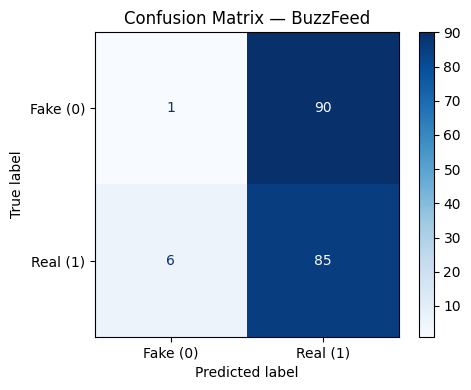

In [10]:
# --- Chargement du modèle pré-entraîné (LIAR dataset) ---
with open(IFACE_DIR / "model.pkl", "rb") as f:
    model = pickle.load(f)
with open(IFACE_DIR / "vectorizer.pkl", "rb") as f:
    vec = pickle.load(f)

tfidf  = vec["tfidf"]
scaler = vec["scaler"]

# --- Vectorisation avec le TF-IDF LIAR (transform uniquement, sans réentraînement) ---
X_tfidf = tfidf.transform(X)
print(f"Features TF-IDF : {X_tfidf.shape[1]}")

# --- Features numériques à zéro (pas d'historique locuteur dans ce dataset) ---
# Le modèle attend 6 features : barely_true, false, half_true, mostly_true, pants_fire, party_encoded
zeros = np.zeros((len(X), 6))
X_num  = csr_matrix(scaler.transform(zeros))
X_full = hstack([X_tfidf, X_num])

# --- Prédictions ---
y_pred = model.predict(X_full)
y_prob = model.predict_proba(X_full)[:, 1]

acc = accuracy_score(y, y_pred)
f1  = f1_score(y, y_pred, average="weighted")
auc = roc_auc_score(y, y_prob)

print(f"\n{'='*40}")
print(f"  Accuracy    : {acc:.4f}")
print(f"  F1 weighted : {f1:.4f}")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, y_pred, target_names=["Fake (0)", "Real (1)"]))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Fake (0)", "Real (1)"]).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — BuzzFeed")
plt.tight_layout()
plt.show()